### Activity 1

In [6]:
# Step 1: Install Required Libraries (Run once)
!pip install tensorflow matplotlib pillow

# Step 2: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Step 3: Load and Preprocess MNIST Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0  # Normalize
x_test = x_test / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Step 4: Build ANN Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train the Model
model.fit(x_train, y_train_cat, epochs=5, validation_split=0.1)

# Step 7: Evaluate the Model
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f"\nTest Accuracy: {accuracy:.4f}")


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8699 - loss: 0.4598 - val_accuracy: 0.9668 - val_loss: 0.1145
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.1090 - val_accuracy: 0.9725 - val_loss: 0.0969
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9758 - loss: 0.0760 - val_accuracy: 0.9723 - val_loss: 0.0999
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9767 - val_loss: 0.0741
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9868 - loss: 0.0416 - val_accuracy: 0.9780 - val_loss: 0.0792
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9710 - loss: 0.0945

Test Accuracy: 0.9756


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Predicted Digit: 3


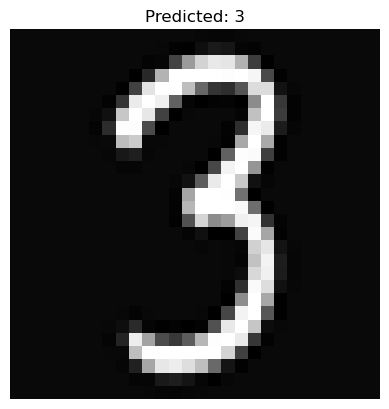

In [22]:
# Step 8: Load Your Own Digit and Predict
img = Image.open("3.png").convert('L')   # Convert to grayscale
img = img.resize((28, 28))                   # Resize to 28x28
img_arr = np.array(img)
img_arr = 255 - img_arr                      # Invert (white background to black)
img_arr = img_arr / 255.0                    # Normalize
img_arr = img_arr.reshape(1, 28, 28)         # Reshape for model

# Predict using trained model
prediction = model.predict(img_arr)
predicted_digit = np.argmax(prediction)

# Show result
print(f"\nPredicted Digit: {predicted_digit}")
plt.imshow(img_arr[0], cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()


### Activity 2

Epoch 1/5


D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.9050 - loss: 0.3121 - val_accuracy: 0.9870 - val_loss: 0.0436
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 75s 41ms/step - accuracy: 0.9858 - loss: 0.0471 - val_accuracy: 0.9897 - val_loss: 0.0363
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 61s 36ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9895 - val_loss: 0.0406
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.9933 - loss: 0.0217 - val_accuracy: 0.9912 - val_loss: 0.0319
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9890 - val_loss: 0.0384
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9858 - loss: 0.0446

 Test Accuracy with CNN: 0.9887
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


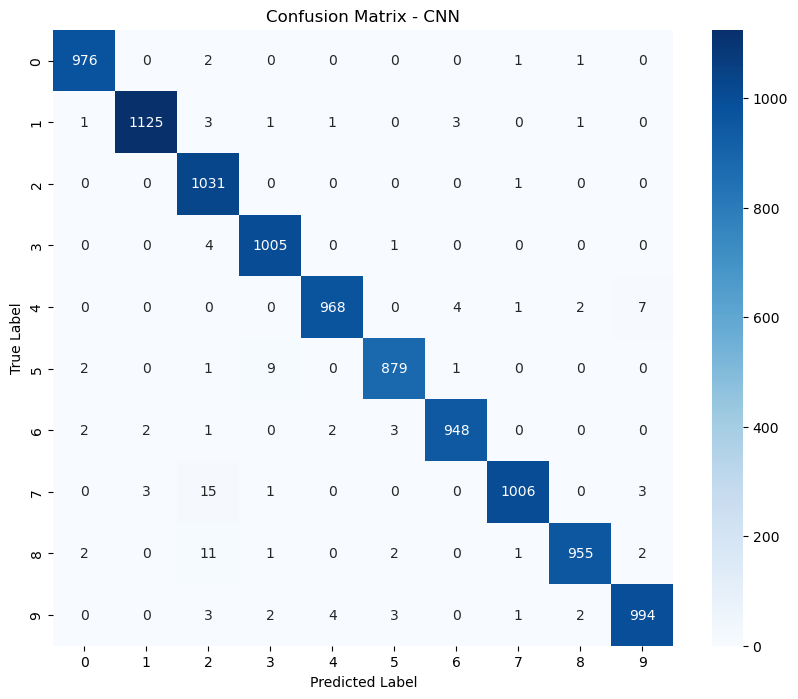


 Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.96      1.00      0.98      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



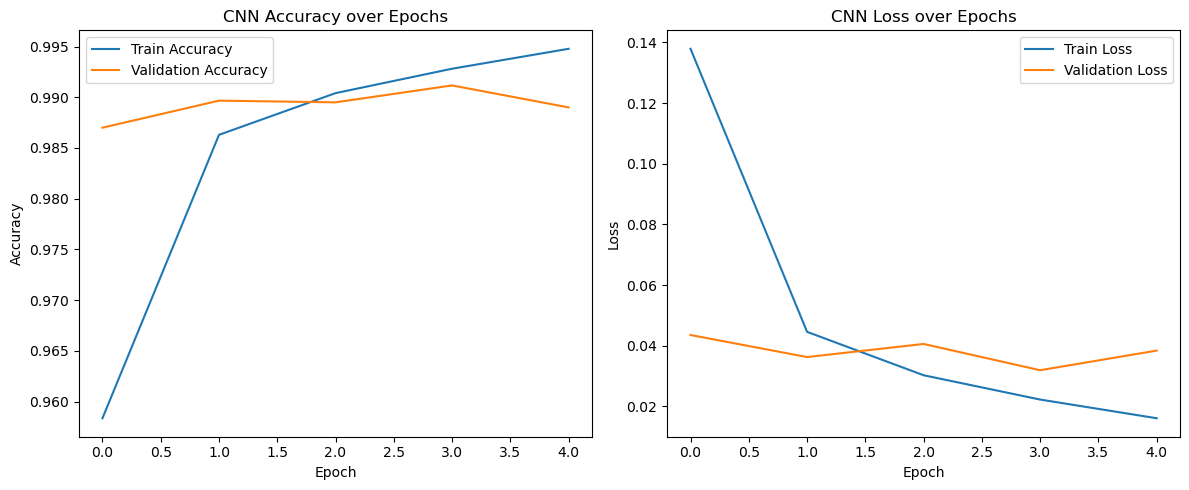

In [37]:
# Install Required Libraries (Run once)
# !pip install tensorflow matplotlib seaborn scikit-learn

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load and Preprocess MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Model
history = model.fit(x_train, y_train_cat, epochs=5, validation_split=0.1)

# Evaluate on Test Set
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\n Test Accuracy with CNN: {test_acc:.4f}")

# Predict Classes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred_classes))

# Accuracy and Loss Visualization
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("CNN Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


### Activity 3

In [42]:
# Step 1: Install Required Libraries (run once)
# !pip install tensorflow matplotlib

# Step 2: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Step 3: Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Step 4: Build ANN Model
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 5: Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train the Model
history = model.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 216s 1us/step


D:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.2819 - loss: 2.0539 - val_accuracy: 0.3540 - val_loss: 1.8311
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3906 - loss: 1.7071 - val_accuracy: 0.4222 - val_loss: 1.6268
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4286 - loss: 1.6064 - val_accuracy: 0.4082 - val_loss: 1.6643
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4530 - loss: 1.5376 - val_accuracy: 0.4338 - val_loss: 1.5989
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4630 - loss: 1.5127 - val_accuracy: 0.4354 - val_loss: 1.5826
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4793 - loss: 1.4651 - val_accuracy: 0.4660 - val_loss: 1.5137
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.4811 - loss: 1.4462 - val_accuracy: 0.4612 - val_loss: 1.5172
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4975 - loss: 1.4107 - 

In [44]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\n Test Accuracy on CIFAR-10 (ANN): {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4809 - loss: 1.4527

 Test Accuracy on CIFAR-10 (ANN): 0.4806


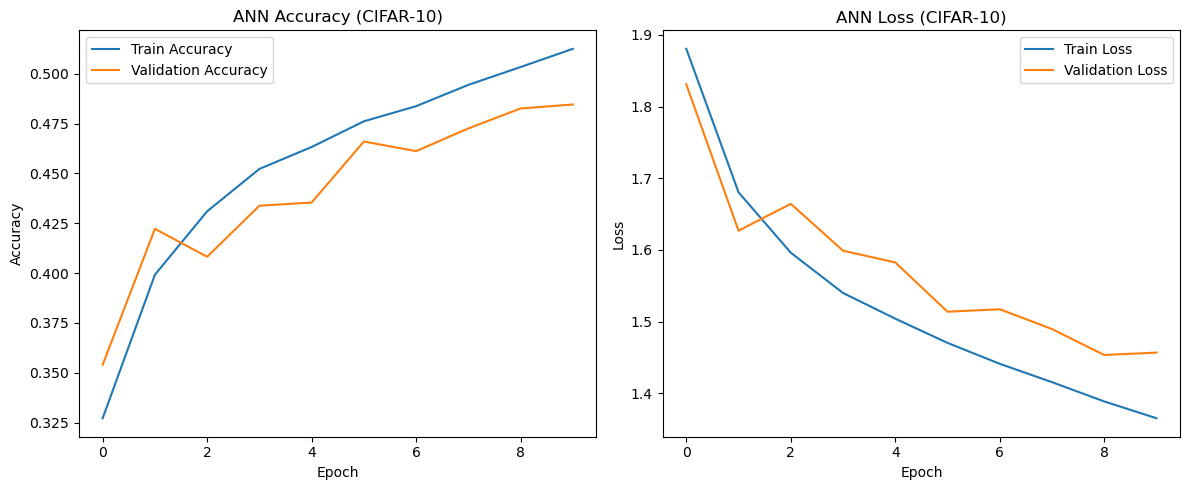

In [46]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ANN Accuracy (CIFAR-10)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ANN Loss (CIFAR-10)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


### Activity 4

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 111ms/step - accuracy: 0.2752 - loss: 1.9357 - val_accuracy: 0.4850 - val_loss: 1.3848
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.4909 - loss: 1.4081 - val_accuracy: 0.5584 - val_loss: 1.2064
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.5596 - loss: 1.2391 - val_accuracy: 0.6218 - val_loss: 1.0722
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.6145 - loss: 1.0975 - val_accuracy: 0.6660 - val_loss: 0.9771
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.6426 - loss: 1.0178 - val_accuracy: 0.6796 - val_loss: 0.9123
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.6765 - loss: 0.9275 - val_accuracy: 0.6976 - val_loss: 0.8591
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.6990 - loss: 0.8653 - val_accuracy: 0.7134 - val_loss: 0.8195
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.7188 - loss: 0.80

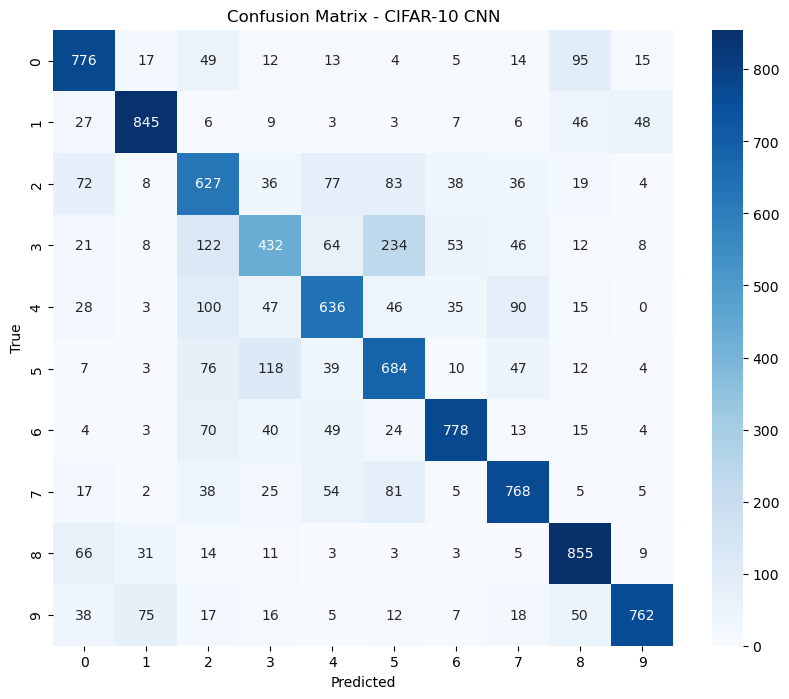

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1000
           1       0.85      0.84      0.85      1000
           2       0.56      0.63      0.59      1000
           3       0.58      0.43      0.49      1000
           4       0.67      0.64      0.65      1000
           5       0.58      0.68      0.63      1000
           6       0.83      0.78      0.80      1000
           7       0.74      0.77      0.75      1000
           8       0.76      0.85      0.81      1000
           9       0.89      0.76      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



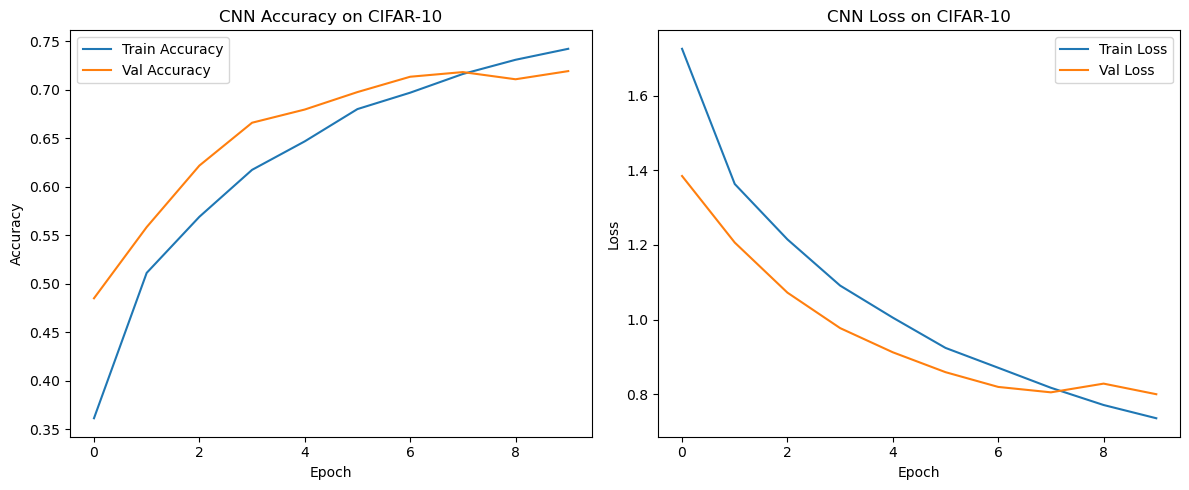

In [48]:
# Step 1: Install Required Libraries (only once)
# !pip install tensorflow matplotlib

# Step 2: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

#Step 4: Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#Step 5: Train the Model
history = model.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.1)

#Step 6: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\n Test Accuracy on CIFAR-10 (CNN): {test_acc:.4f}")

#Step 7: Confusion Matrix & Classification Report
# Predict
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes))

#Step 8: Plot Training History
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy on CIFAR-10")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN Loss on CIFAR-10")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
